ABOUT THE PROJECT
1. Create a business case
2. Prepare the data
3. Data analysis and exploration
4. Clustering analysis
5. Choosing optimal hyperparameters
7. Visualization and interpretation

What is customer segmentation
1. Determine customers to sell products
2. Applying clustering algorithm 
3. Sell product to targeted customers


Types of Segmentaton factors
1. demographic- age, gender, income...
2. psychogrpahic - interests, lifestyle , motivations ...
3. Behavioural - purchasing habits, spending habits, user status...
4. Geographic - ZIP code, city , country...

Advantages of Customer Segmentation
1. Price Optimization
2. Enhances Competitiveness
3. Brand Awareness
4. Acquistion & Retention
5. Increases Revenue & RQI

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_excel("Mall Customers.xlsx")

In [5]:
df

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40
...,...,...,...,...,...,...,...
195,196,F,35,High School,Married,120,79
196,197,F,45,High School,Unknown,126,28
197,198,M,32,Uneducated,Married,126,74
198,199,M,32,High School,Married,137,18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [7]:
df.shape

(200, 7)

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

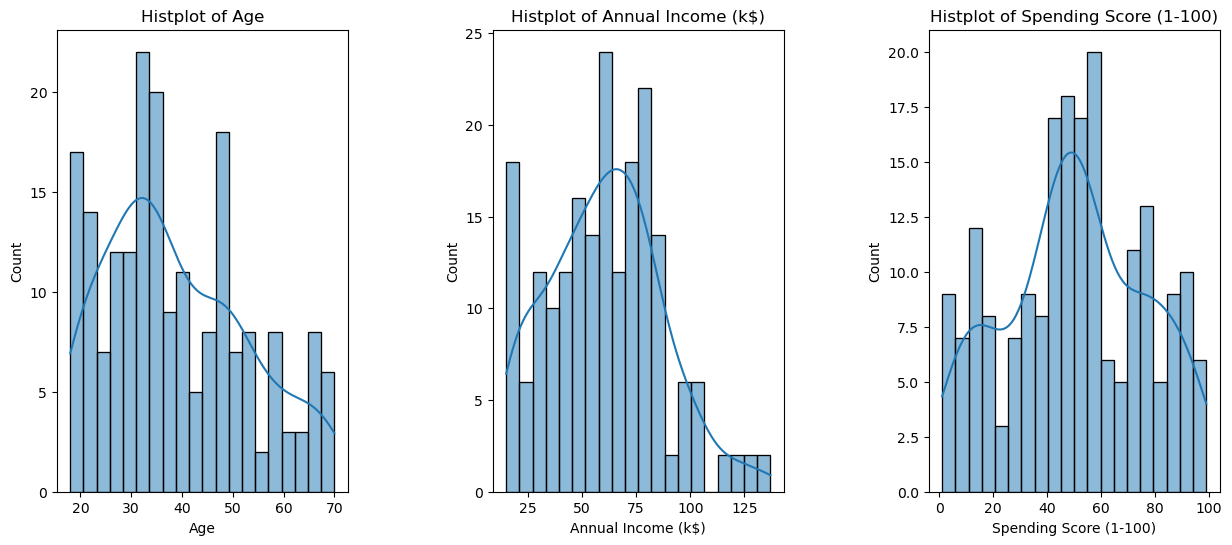

In [19]:
plt.figure(1, figsize=(15,6))
n = 0 
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n +=1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
    sns.histplot(df[x], bins = 20, kde = True)
    plt.title('Histplot of {}'.format(x))
plt.show()

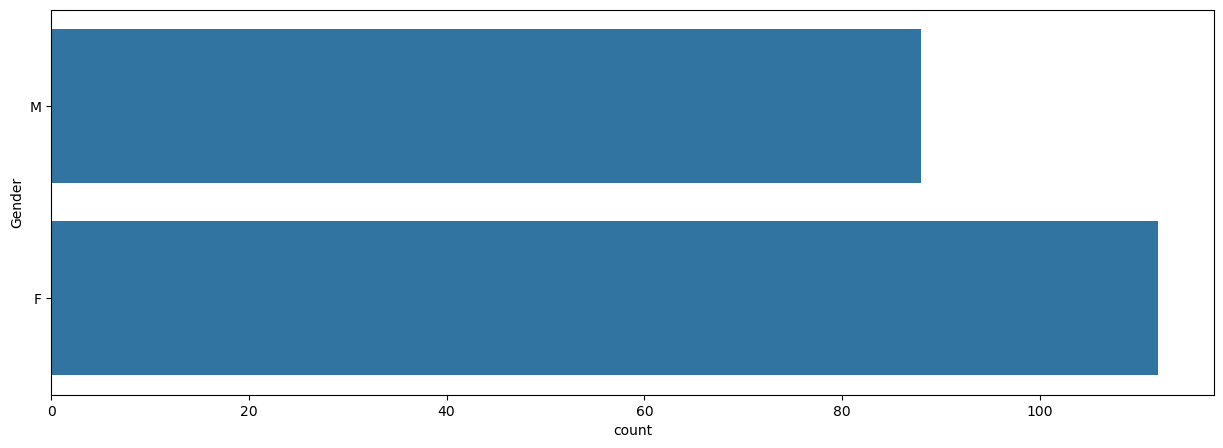

In [20]:
plt.figure(figsize =(15,5))
sns.countplot(y='Gender', data = df)
plt.show()

/var/folders/0k/07ldk2fn76v9l5gr9yxytv540000gn/T/ipykernel_23022/1726553391.py:1: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(15,6))


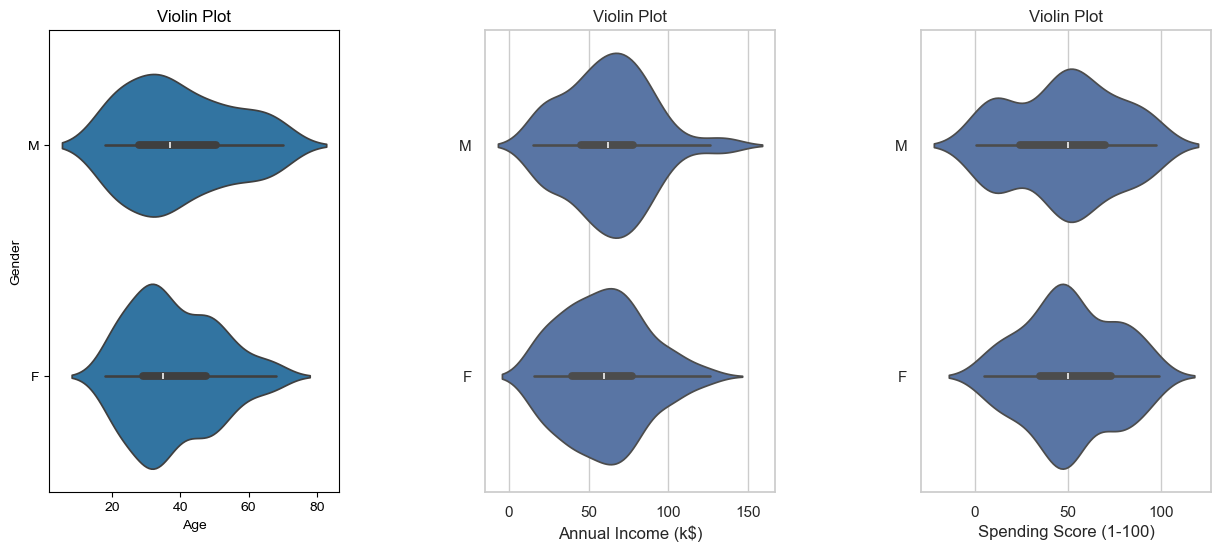

In [23]:
plt.figure(1, figsize=(15,6))
n = 0 
for cols in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n +=1
    plt.subplot(1,3,n)
    sns.set(style = 'whitegrid')
    plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
    sns.violinplot(x = cols, y = 'Gender', data = df)
    plt.ylabel('Gender' if n == 1 else "")
    plt.title('Violin Plot')
plt.show()

/var/folders/0k/07ldk2fn76v9l5gr9yxytv540000gn/T/ipykernel_23022/4209324044.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = agex, y = agey, palette = 'mako')


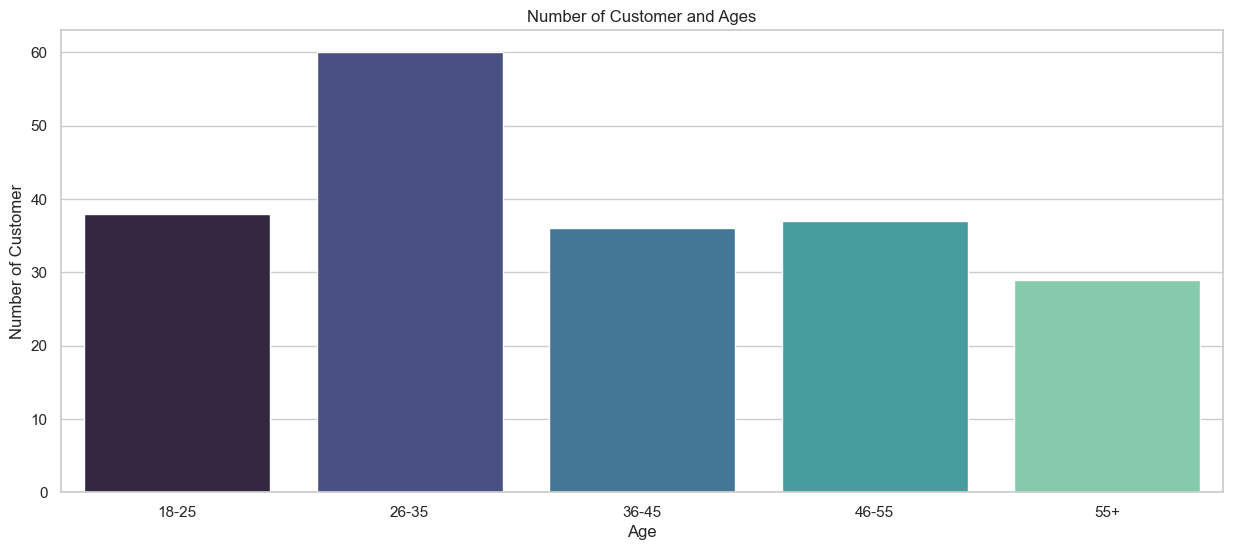

In [25]:
age_18_25 = df.Age[(df.Age >= 18) & (df.Age <= 25)]
age_26_35 = df.Age[(df.Age >= 26) & (df.Age <= 35)]
age_36_45 = df.Age[(df.Age >= 36) & (df.Age <= 45)]
age_46_55 = df.Age[(df.Age >= 46) & (df.Age <= 55)]
age_55above = df.Age[df.Age >= 56]

agex = ['18-25', '26-35', '36-45', '46-55', '55+']
agey= [len(age_18_25), len(age_26_35), len(age_36_45), len(age_46_55), len(age_55above)]

plt.figure(figsize = (15,6))
sns.barplot(x = agex, y = agey, palette = 'mako')
plt.title("Number of Customer and Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customer")
plt.show()

/var/folders/0k/07ldk2fn76v9l5gr9yxytv540000gn/T/ipykernel_23022/1217653894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = aix, y = aiy, palette = 'Spectral')


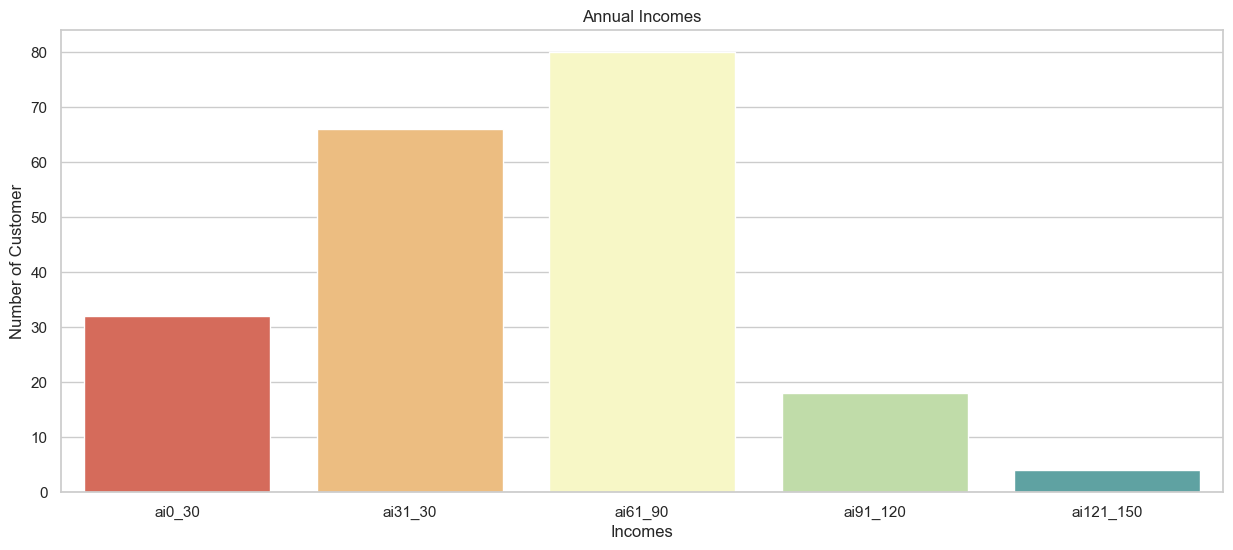

In [28]:
ai0_30 = df['Annual Income (k$)'][(df['Annual Income (k$)'] >=0) & (df['Annual Income (k$)']<=30)]
ai31_60 = df['Annual Income (k$)'][(df['Annual Income (k$)'] >=31) & (df['Annual Income (k$)']<=60)]
ai61_90 = df['Annual Income (k$)'][(df['Annual Income (k$)'] >=61) & (df['Annual Income (k$)']<=90)]
ai91_120 = df['Annual Income (k$)'][(df['Annual Income (k$)'] >=91) & (df['Annual Income (k$)']<=120)]
ai121_150 = df['Annual Income (k$)'][(df['Annual Income (k$)'] >=121) & (df['Annual Income (k$)']<=150)]
aix = ['ai0_30', 'ai31_30', 'ai61_90', 'ai91_120', 'ai121_150']
aiy= [len(ai0_30), len(ai31_60), len(ai61_90), len(ai91_120), len(ai121_150)]

plt.figure(figsize = (15,6))
sns.barplot(x = aix, y = aiy, palette = 'Spectral')
plt.title("Annual Incomes")
plt.xlabel("Incomes")
plt.ylabel("Number of Customer")
plt.show()

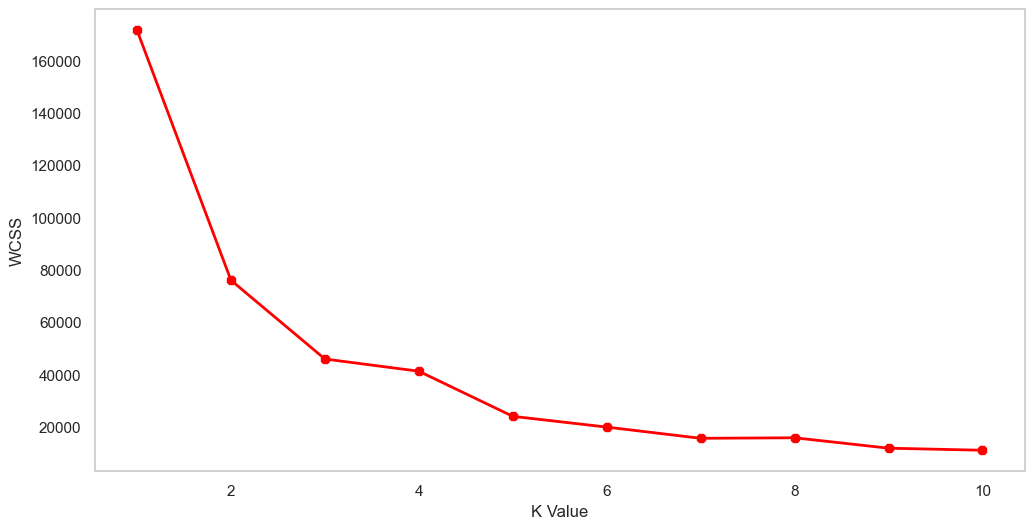

In [31]:
X1 = df.loc[:, ['Age', 'Spending Score (1-100)']].values

from sklearn.cluster import KMeans
wcss= []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(12,6))
plt.grid()
plt.plot(range(1,11), wcss, linewidth=2, color ='red', marker = '8')
plt.xlabel("K Value")
plt.ylabel('WCSS')
plt.show()

In [33]:
kmeans = KMeans(n_clusters = 4)
label = kmeans.fit_predict(X1)
print(label)

[3 2 1 2 3 2 1 2 1 2 1 2 1 2 1 2 3 3 1 2 3 2 1 2 1 2 1 3 1 2 1 2 1 2 1 2 1
 2 1 2 0 2 0 3 1 3 0 3 3 3 0 3 3 0 0 0 0 0 3 0 0 3 0 0 0 3 0 0 3 3 0 0 0 0
 0 3 0 3 3 0 0 3 0 0 3 0 0 3 3 0 0 3 0 3 3 3 0 3 0 3 3 0 0 3 0 3 0 0 0 0 0
 3 3 3 3 3 0 0 0 0 3 3 3 2 3 2 0 2 1 2 1 2 3 2 1 2 1 2 1 2 1 2 3 2 1 2 0 2
 1 2 1 2 1 2 1 2 1 2 1 2 0 2 1 2 1 2 1 2 1 3 1 2 1 2 1 2 1 2 1 2 1 2 1 2 3
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [34]:
print(kmeans.cluster_centers_)


[[55.70833333 48.22916667]
 [43.29166667 15.02083333]
 [30.1754386  82.35087719]
 [27.61702128 49.14893617]]


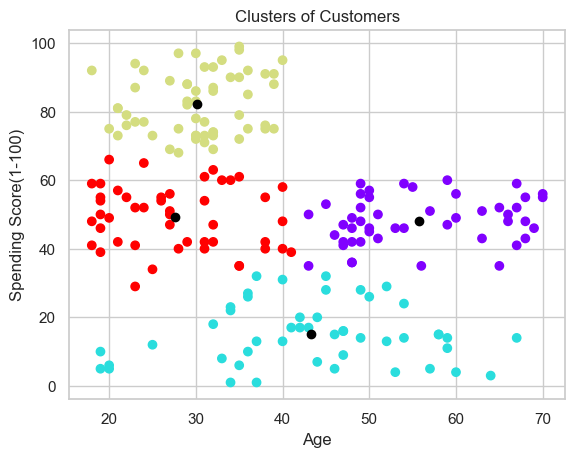

In [35]:
plt.scatter(X1[:,0], X1[:,1], c = kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black')
plt.title('Clusters of Customers')
plt.xlabel('Age')
plt.ylabel('Spending Score(1-100)')
plt.show()

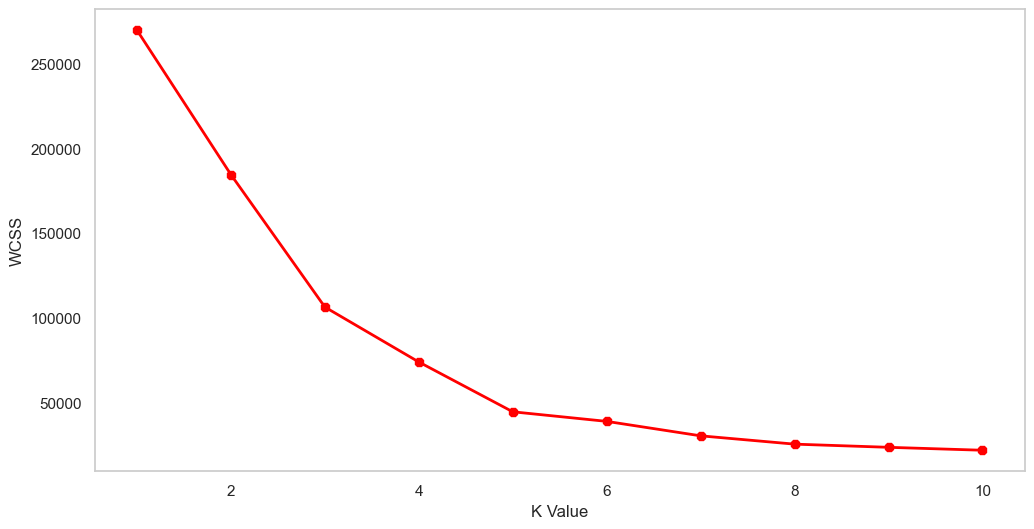

In [37]:
X2 = df.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']].values

from sklearn.cluster import KMeans
wcss= []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(12,6))
plt.grid()
plt.plot(range(1,11), wcss, linewidth=2, color ='red', marker = '8')
plt.xlabel("K Value")
plt.ylabel('WCSS')
plt.show()

In [38]:
kmeans = KMeans(n_clusters = 5)
label = kmeans.fit_predict(X2)
print(label)

[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 4 0 4 1 4 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 2 3 1 3 2 3 2 3 1 3 2 3 2 3 2 3 2 3 1 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


In [39]:
print(kmeans.cluster_centers_)

[[25.72727273 79.36363636]
 [55.2962963  49.51851852]
 [88.2        17.11428571]
 [86.53846154 82.12820513]
 [26.30434783 20.91304348]]


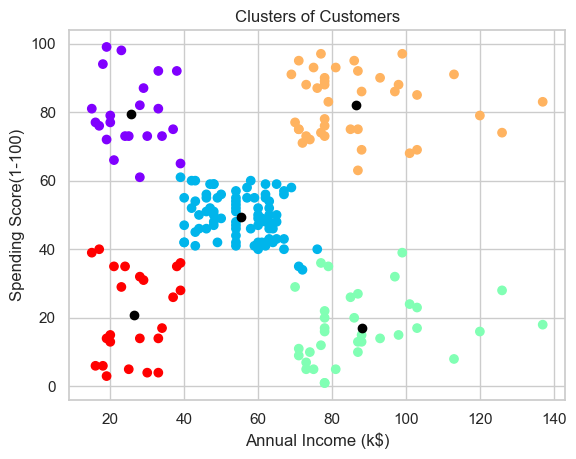

In [40]:
plt.scatter(X2[:,0], X2[:,1], c = kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.show()

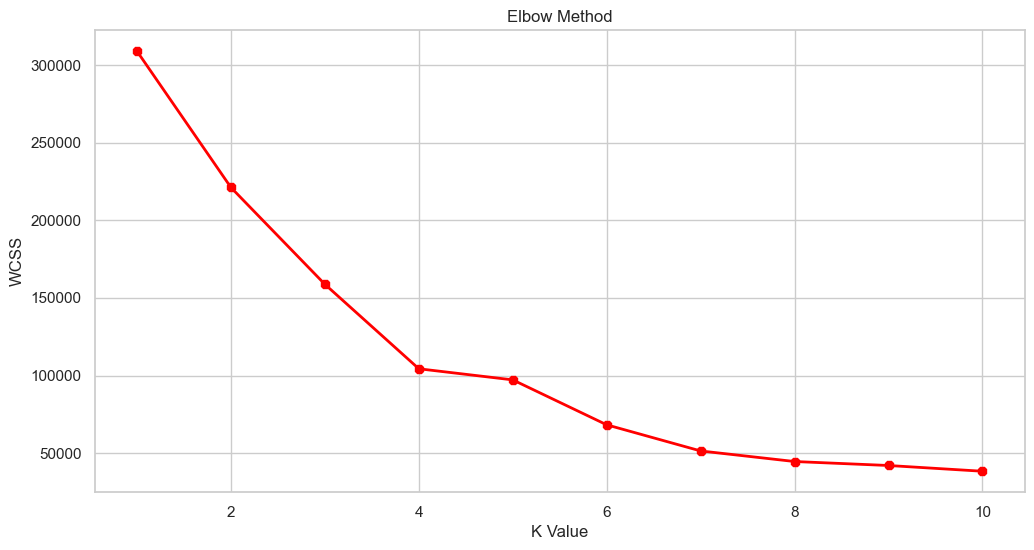

In [44]:
# Select only numeric columns
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X3)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(1,11), wcss, marker='8', color='red', linewidth=2)
plt.grid(True)
plt.xlabel('K Value')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


In [45]:
kmeans = KMeans(n_clusters = 5)
label = kmeans.fit_predict(X3)
print(label)

[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 4 1 0 1 0 1 4 0 0 0 4 0 0 4 4 0 4 4 0 4 4 0 4 4 4 0 4 4 0 0 4 4 4 4
 4 0 4 4 0 4 4 4 4 4 0 4 4 0 4 4 4 0 4 4 0 0 4 0 4 0 0 4 4 4 4 0 4 4 4 4 4
 0 4 0 0 0 4 4 4 4 4 4 4 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2]


In [46]:
print(kmeans.cluster_centers_)

[[33.75       40.64583333 36.16666667]
 [25.52173913 26.30434783 78.56521739]
 [32.69230769 86.53846154 82.12820513]
 [40.39473684 87.         18.63157895]
 [52.94230769 55.28846154 49.73076923]]


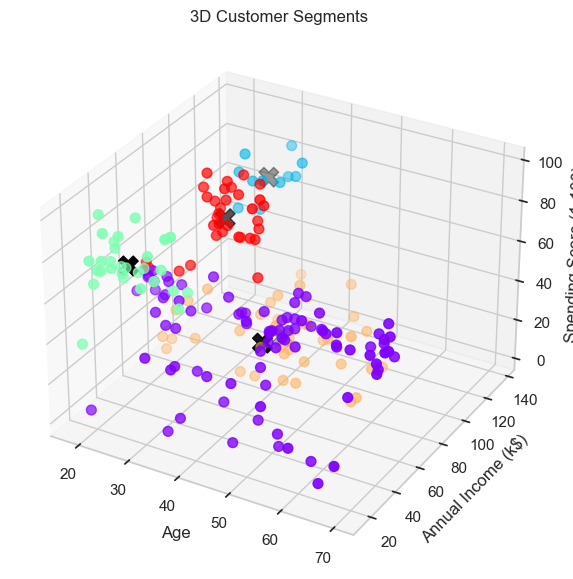

In [47]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Select only numeric columns from X3
X3_numeric = X3[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Fit K-Means (choose k based on your elbow plot)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X3_numeric)

# 3D scatter plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter points colored by cluster
ax.scatter(
    X3_numeric['Age'], 
    X3_numeric['Annual Income (k$)'], 
    X3_numeric['Spending Score (1-100)'], 
    c=y_kmeans, 
    cmap='rainbow', 
    s=50
)

# Cluster centers
ax.scatter(
    kmeans.cluster_centers_[:,0],  # Age
    kmeans.cluster_centers_[:,1],  # Annual Income
    kmeans.cluster_centers_[:,2],  # Spending Score
    s=200, color='black', marker='X'
)

# Labels
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Customer Segments')

plt.show()

